In [1]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps import logger
from gulps.core.coverage import coverage_report
from gulps.core.invariants import GateInvariants
from gulps.core.isa import ISAInvariants
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.viz.invariant_viz import render_path

/home/evm9/hetero_isas/src/gulps/core/jax_invariants.py:21: UserWarning: Explicitly requested dtype complex128 requested in array is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  MAGIC = jnp.array(
/home/evm9/hetero_isas/src/gulps/core/jax_invariants.py:57: UserWarning: Explicitly requested dtype complex128 requested in array is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  _SY = jnp.array([[0, -1j], [1j, 0]], dtype=jnp.complex128)
/home/evm9/hetero_isas/src/gulps/core/jax_invariants.py:60: UserWarning: Explicitly requested dtype float64 requested in array is not available, and will be truncated to dtype float32.

### Usage as a Decomposer

In [2]:
# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (CXGate().power(1 / 6), 1 / 6, "sqrt6cx"),
    # (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 6), 1 / 6, "sqrt6iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 1.0, "swap"),
    # (SwapGate().power(1 / 2), 1 / 2, "eswap"),
    # (SwapGate().power(1 / 3), 1 / 3, "eswap"),
]
gate_set, costs, names = zip(*isa)
isa = ISAInvariants(gate_set, costs, names, precompute_polytopes=False)
decomposer = GulpsDecomposer(isa=isa)

In [3]:
if hasattr(decomposer.isa, "coverage_set"):
    report = coverage_report(decomposer.isa.coverage_set)

In [4]:
logger.setLevel("INFO")
N = 1_000

# Warm-start to trigger JIT compilation (optional)
_ = decomposer(random_unitary(4, seed=0))

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        v = Operator(decomposer(u))
        fid = average_gate_fidelity(u, v)

        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")

        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)

    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

# === Fidelity Statistics ===
fidelities = np.array(fidelities)
print(f"\n✔ Completed {len(fidelities)} successful runs (out of {N})")
print(f"  → Failures: {failures}")
print(f"  → Median Fidelity: {np.median(fidelities)}")
print(f"  → Mean Fidelity:   {np.mean(fidelities)}")
print(f"  → Min Fidelity:    {np.min(fidelities)}")

# === Timing Statistics ===
if all_timings:
    phase_names = list(all_timings[0].keys())
    timing_array = np.array([[t[k] for k in phase_names] for t in all_timings])

    print("\nAverage phase durations:")
    for k, mean_time in zip(phase_names, timing_array.mean(axis=0)):
        print(f"  {k:>10}: {mean_time:.4f} s")

    print(f"\n  Total average time: {timing_array.sum(axis=1).mean():.4f} s")
else:
    print("No successful timings collected.")

Decomposing random unitaries:  36%|███▌      | 361/1000 [00:14<00:31, 20.28it/s]

[WARN] Failed on unitary 358: 'TwoQubitWeylDecomposition: failed to diagonalize M2. Please report this at https://github.com/Qiskit/qiskit-terra/issues/4159. Input: [[Complex { re: 0.09508905546307951, im: 0.4930903665926457 }, Complex { re: 0.21924299941307399, im: -0.3382940491423411 }, Complex { re: 0.392512928596501, im: 0.3885413161041656 }, Complex { re: -0.03617294742512506, im: 0.528176457130701 }],\n [Complex { re: 0.204198284416828, im: 0.7511317443800181 }, Complex { re: -0.3482641078257751, im: 0.14639095612555109 }, Complex { re: -0.0704110376500118, im: -0.23637503528986725 }, Complex { re: -0.3213300092164707, im: -0.29546931488149364 }],\n [Complex { re: -0.30652680256799286, im: -0.07457242028198491 }, Complex { re: -0.3788857680163446, im: -0.09116909215849264 }, Complex { re: -0.1852004764182279, im: -0.4466030477914393 }, Complex { re: -0.2495070677587781, im: 0.672760558628914 }],\n [Complex { re: 0.14852388189365276, im: 0.14263609318390766 }, Complex { re: 0.4521

Decomposing random unitaries:  53%|█████▎    | 532/1000 [00:21<00:37, 12.64it/s]

[WARN] Failed on unitary 529: Stage 1 (Makhlin) failed: best residual 1.58e-07


Decomposing random unitaries:  84%|████████▍ | 843/1000 [00:33<00:05, 27.23it/s]

[WARN] Failed on unitary 838: Cannot recover local equivalence; Weyl differences [1.35512770e-05 1.17380585e-05 7.35482521e-07]


Decomposing random unitaries: 100%|██████████| 1000/1000 [00:40<00:00, 24.83it/s]


✔ Completed 997 successful runs (out of 1000)
  → Failures: 3
  → Median Fidelity: 0.9999999999999961
  → Mean Fidelity:   0.9999999999975138
  → Min Fidelity:    0.9999999997256118

Average phase durations:
  lp_sentence: 0.0035 s
    segments: 0.0347 s

  Total average time: 0.0382 s


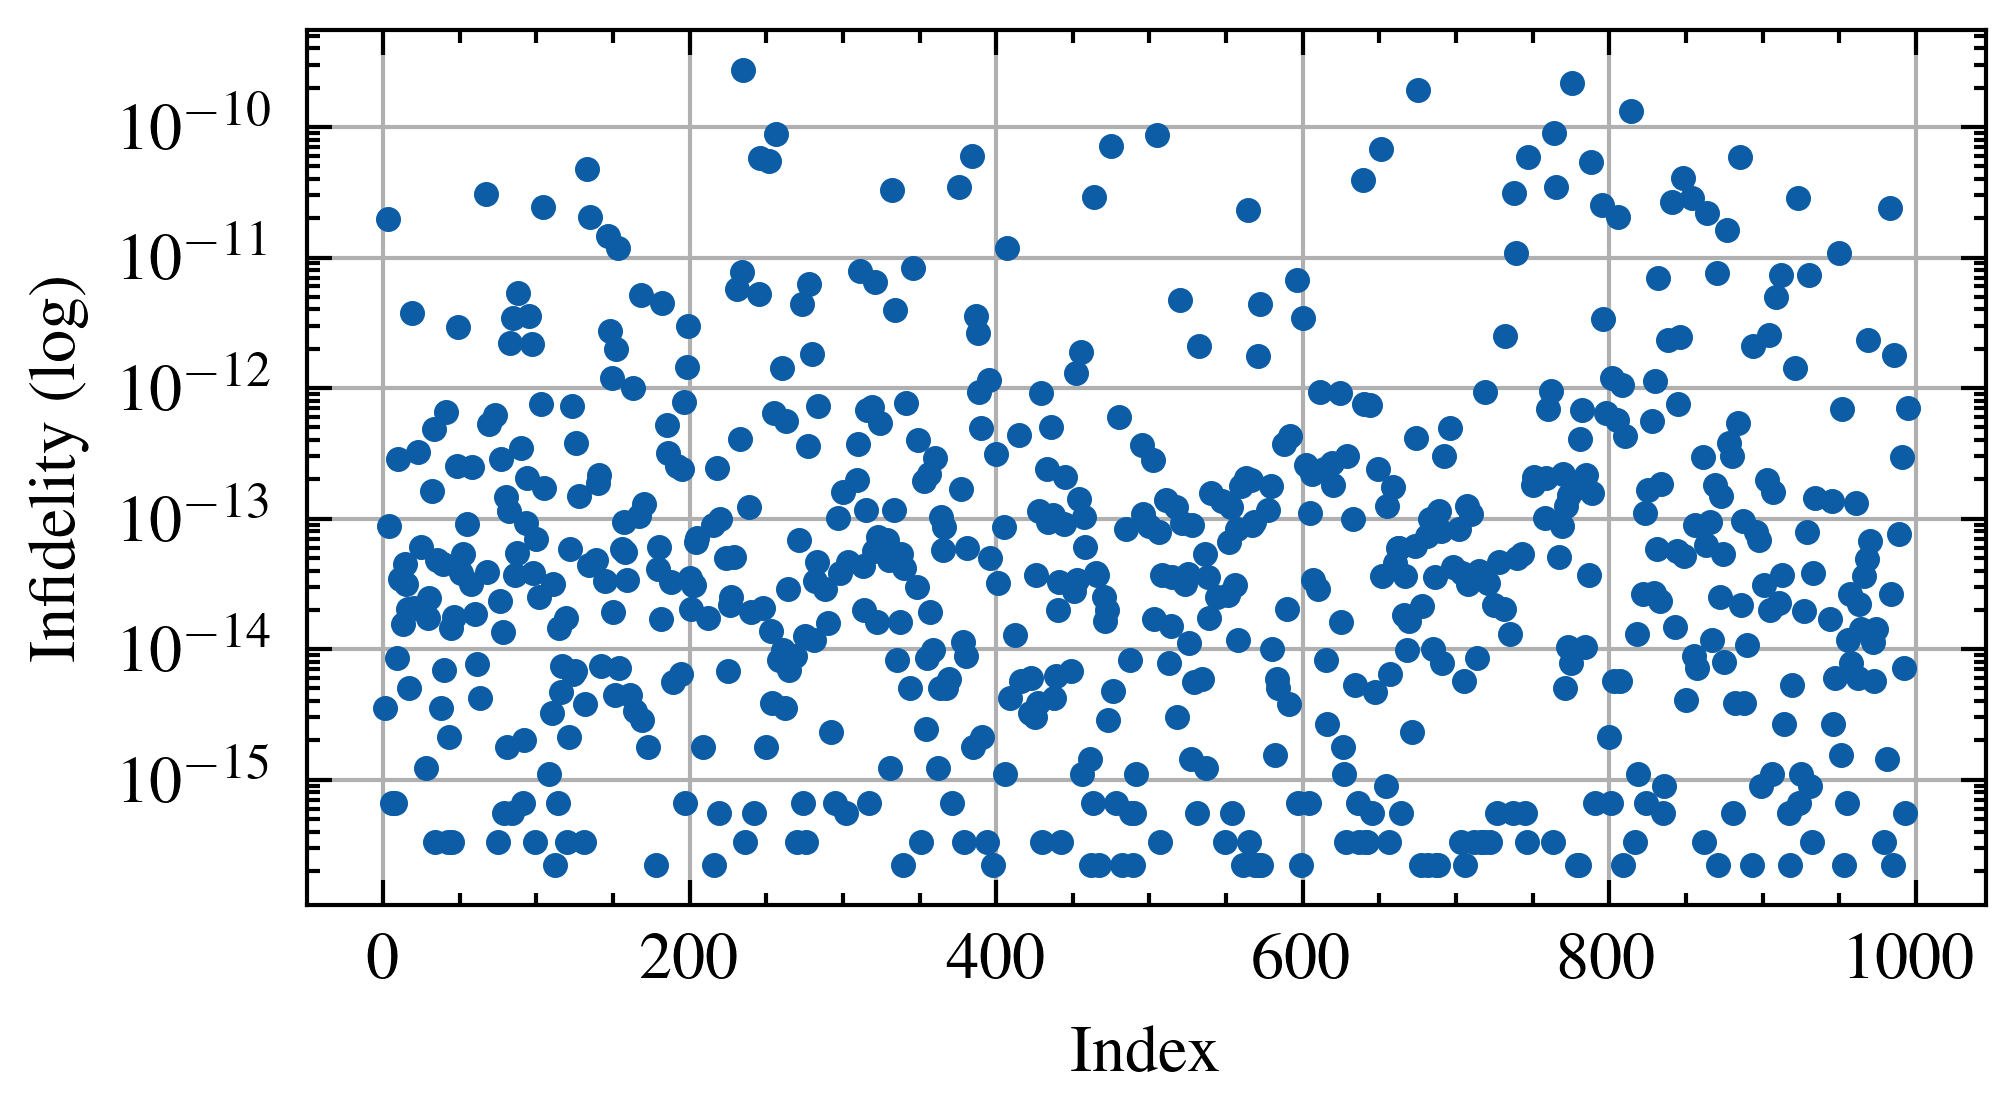

In [5]:
# make a plot for the fidelities
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(3.5, 2))
    ax.plot(1 - fidelities, marker="o", markersize=2, linestyle="None")
    ax.set_xlabel("Index")
    ax.set_ylabel("Infidelity (log)")
    ax.set_yscale("log")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

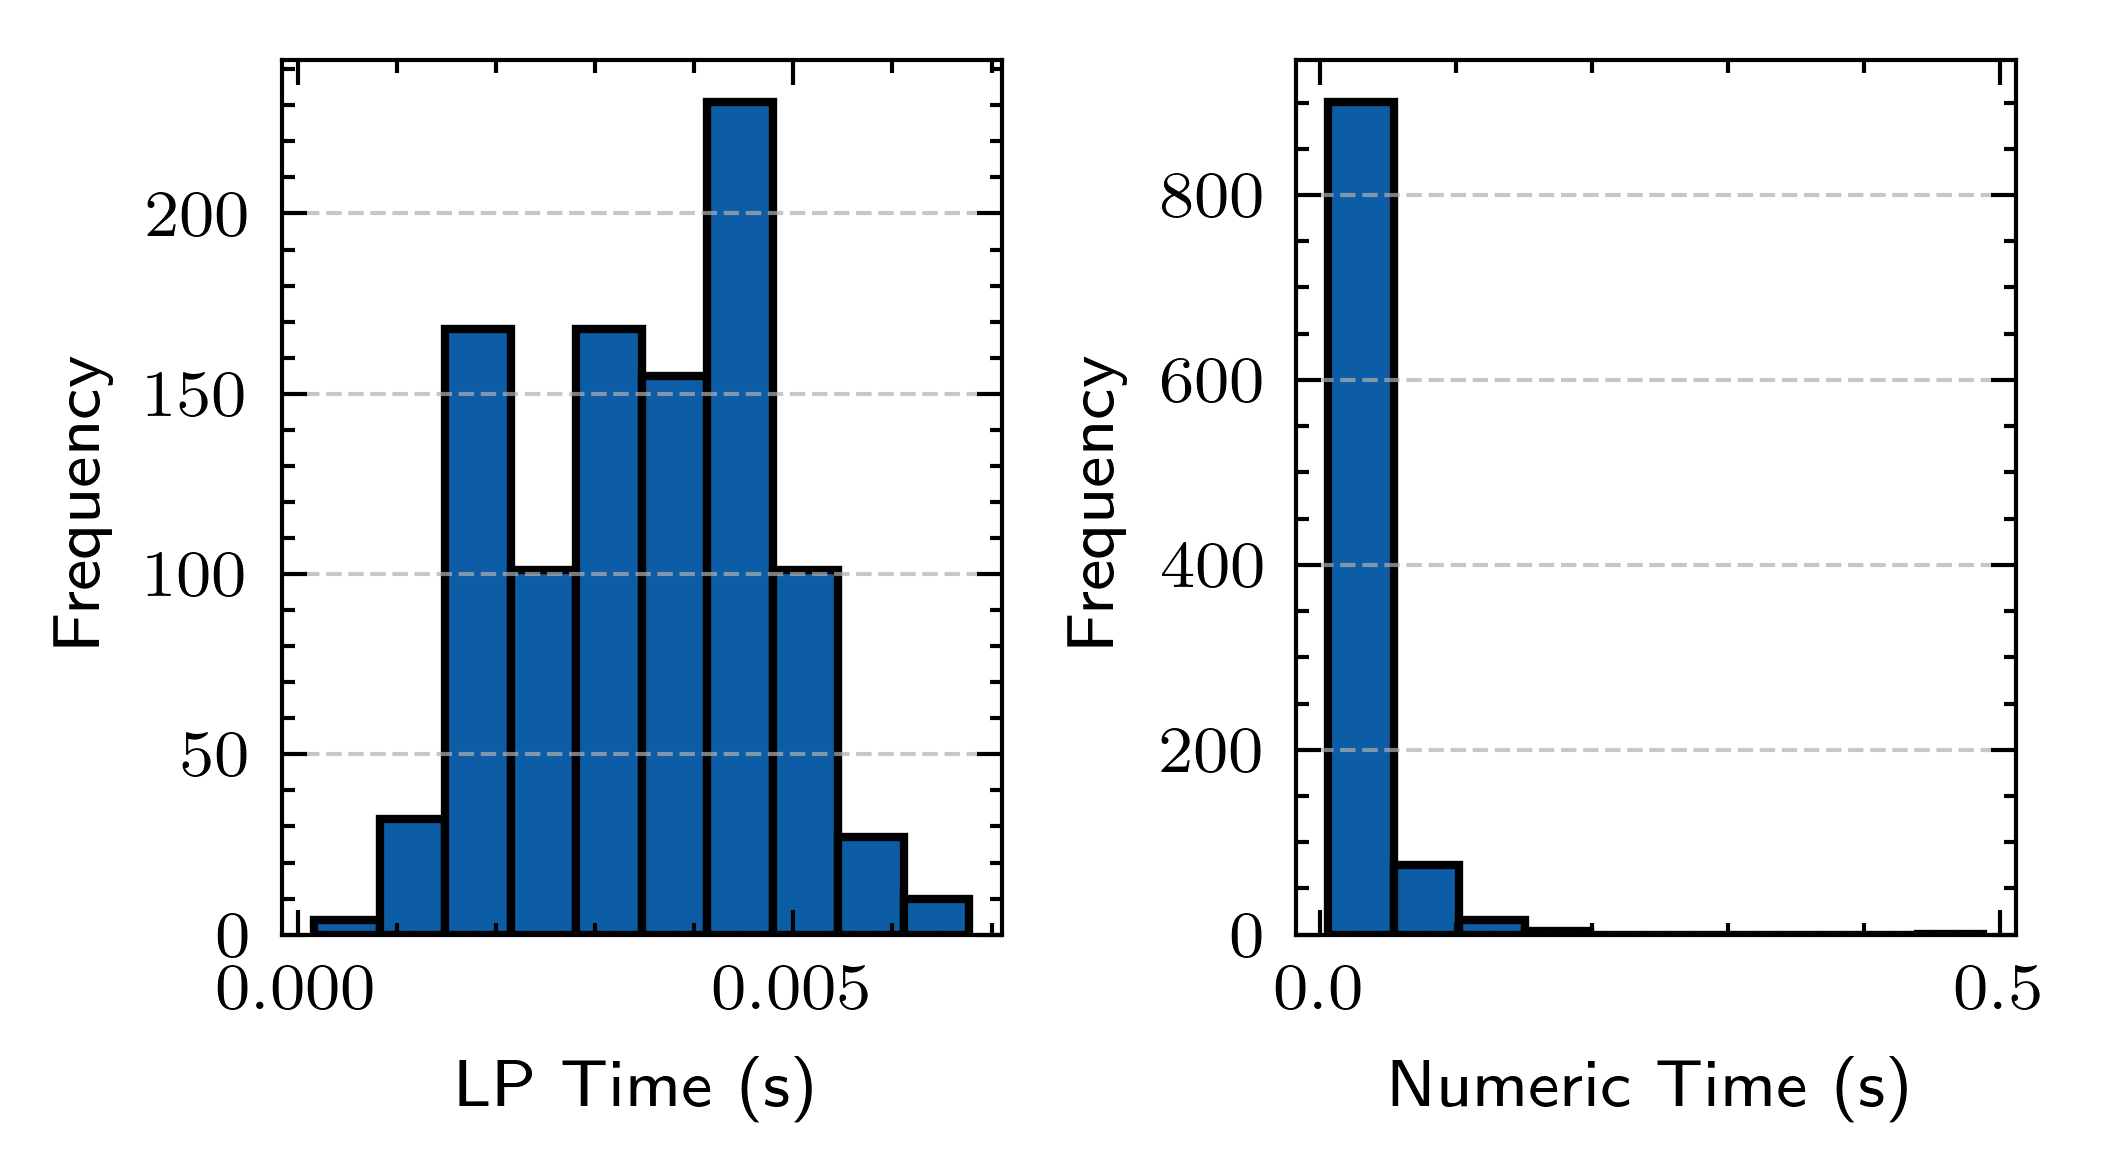

In [6]:
# Convert list of dicts to lists of values
lp_times = [d["lp_sentence"] for d in all_timings]
numeric_times = [d["segments"] for d in all_timings]

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(3.5, 2))

    axes[0].set_xlabel("LP Time (s)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)
    axes[0].hist(lp_times, edgecolor="black")

    axes[1].set_xlabel("Numeric Time (s)")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)
    axes[1].hist(numeric_times, edgecolor="black")

    fig.tight_layout()
plt.show()